# Leaf-Granularity Sweep — GO/NO-GO de-risk gate

**Does leaf granularity affect QASPER gold-evidence retrieval, and is the optimum document-dependent?**

This is a cheap de-risk experiment — **NO LLM, SBERT embeddings only**, so it runs in minutes. We chunk each
paper at several leaf token sizes, build a flat SBERT + FAISS index over the chunks (reusing the project's own
flat-retrieval machinery), run the real QASPER questions through it, and measure how much of the **gold evidence**
lands inside the retrieved context.

It decides one thing: **is density-adaptive chunking worth building?**

- Flat curve, or a single shared peak across all docs ⇒ **no adaptive story** — just pick that fixed size.
- The best size **varies across documents** ⇒ **green light** to build a density-driven adaptive chunker.

Unanswerable questions (no gold evidence) are excluded from the coverage metric.

In [1]:
!git clone -b ckraptor https://github.com/MissLostCodes/raptor.git
%cd raptor
!pip install -q -r requirements-colab.txt

Cloning into 'raptor'...
remote: Enumerating objects: 362, done.
remote: Counting objects: 100% (333/333), done.
remote: Compressing objects: 100% (225/225), done.
remote: Total 362 (delta 150), reused 247 (delta 94), pack-reused 29 (from 1)
Receiving objects: 100% (362/362), 1.16 MiB | 4.54 MiB/s, done.
Resolving deltas: 100% (150/150), done.
/content/raptor
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.8 MB/s eta 0:00:00


## GPU + persistence

SBERT embeddings benefit from a GPU runtime (*Runtime → Change runtime type → GPU*), though CPU also works since
there's no LLM here. We mount Google Drive for `RUN_DIR` so the sweep's JSON output survives a disconnect and the
run resumes instead of recomputing (off Colab this falls back to a local `./raptor_runs`).

In [2]:
# Persist the sweep output to Drive so a disconnect never loses progress; rerun resumes.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUN_DIR = '/content/drive/MyDrive/raptor_runs'
except Exception as e:
    print('Not on Colab / Drive unavailable -> using local ./raptor_runs', e)
    RUN_DIR = 'raptor_runs'

import os
os.makedirs(RUN_DIR, exist_ok=True)
OUT = os.path.join(RUN_DIR, 'granularity_sweep.json')
print('RUN_DIR =', RUN_DIR)
print('OUT     =', OUT)

Mounted at /content/drive
RUN_DIR = /content/drive/MyDrive/raptor_runs
OUT     = /content/drive/MyDrive/raptor_runs/granularity_sweep.json


In [3]:
from experiments.datasets import get_loader

docs = get_loader('qasper').load(limit=8)
n_ans = sum(1 for d in docs for q in d.questions if q.evidence)
print(f'{len(docs)} QASPER papers, {n_ans} answerable (gold-evidence) questions total')

README.md:   0%|          | 0.00/9.64k [00:00<?, ?B/s]

qasper.py:   0%|          | 0.00/5.95k [00:00<?, ?B/s]

qasper/test/0000.parquet:   0%|          | 0.00/7.07M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

8 QASPER papers, 25 answerable (gold-evidence) questions total


In [4]:
from experiments import granularity_sweep as gs

SIZES = [50, 100, 150, 200, 300, 400]   # leaf token sizes to sweep
records = gs.run_sweep(docs, SIZES, budget=2000, out_path=OUT)
print(f'{len(records)} (doc, size) records')
records[:3]

[granularity_sweep] doc 1/8 1911.10742: already complete, skipping
[granularity_sweep] doc 2/8 1904.09131: sweeping sizes [50, 100, 150, 200, 300, 400]


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

48 (doc, size) records


[{'doc_id': '1911.10742',
  'size': 50,
  'n_chunks': 197,
  'n_questions': 4,
  'mean_evidence_coverage': 0.7055555555555555},
 {'doc_id': '1911.10742',
  'size': 100,
  'n_chunks': 87,
  'n_questions': 4,
  'mean_evidence_coverage': 0.7402777777777778},
 {'doc_id': '1911.10742',
  'size': 150,
  'n_chunks': 54,
  'n_questions': 4,
  'mean_evidence_coverage': 0.7680555555555555}]

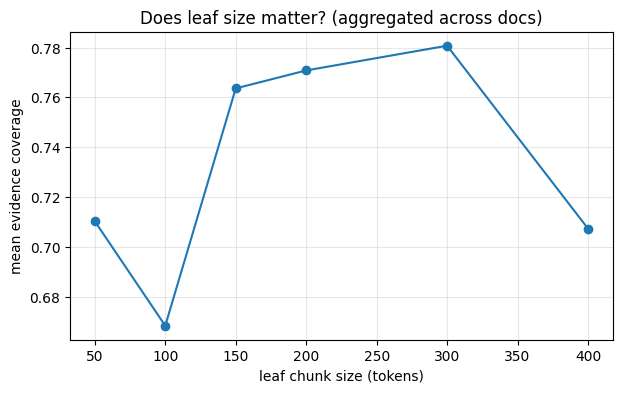

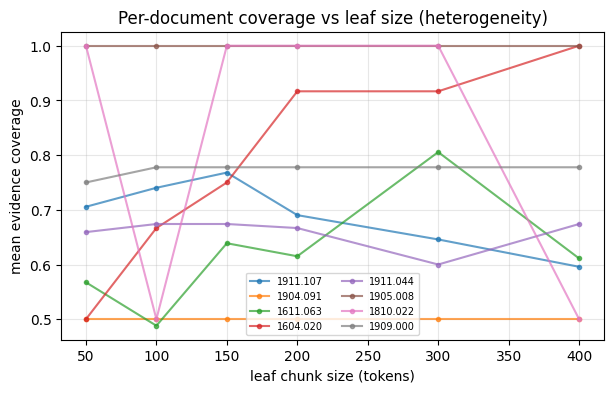

best_size_per_doc: {'1911.10742': 150, '1904.09131': 50, '1611.06322': 300, '1604.02038': 400, '1911.04474': 100, '1905.00840': 50, '1810.02229': 50, '1909.00091': 100}

doc_id           best size
1911.10742             150
1904.09131              50
1611.06322             300
1604.02038             400
1911.04474             100
1905.00840              50
1810.02229              50
1909.00091             100

distribution of argmax sizes: {150: 1, 50: 3, 300: 1, 400: 1, 100: 2}


In [5]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Group coverage by (doc, size), dropping records with no answerable questions.
by_size = defaultdict(list)            # size -> [mean_cov, ...] across docs
per_doc = defaultdict(dict)            # doc_id -> {size: mean_cov}
for r in records:
    cov = r['mean_evidence_coverage']
    if cov is None:
        continue
    by_size[r['size']].append(cov)
    per_doc[r['doc_id']][r['size']] = cov

sizes_sorted = sorted(by_size)

# (a) Aggregate: mean evidence-coverage vs leaf size -- the "does size matter" curve.
agg = [sum(by_size[s]) / len(by_size[s]) for s in sizes_sorted]
plt.figure(figsize=(7, 4))
plt.plot(sizes_sorted, agg, marker='o')
plt.xlabel('leaf chunk size (tokens)')
plt.ylabel('mean evidence coverage')
plt.title('Does leaf size matter? (aggregated across docs)')
plt.grid(True, alpha=0.3)
plt.show()

# (b) Per-doc coverage-vs-size lines -- the heterogeneity picture.
plt.figure(figsize=(7, 4))
for doc_id, d in per_doc.items():
    xs = sorted(d)
    plt.plot(xs, [d[x] for x in xs], marker='.', alpha=0.7, label=doc_id[:8])
plt.xlabel('leaf chunk size (tokens)')
plt.ylabel('mean evidence coverage')
plt.title('Per-document coverage vs leaf size (heterogeneity)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=7, ncol=2)
plt.show()

# (c) argmax leaf size per document.
best = gs.best_size_per_doc(records)
print('best_size_per_doc:', best)
print()
print(f"{'doc_id':<16}{'best size':>10}")
for doc_id, s in best.items():
    print(f'{doc_id[:16]:<16}{s:>10}')
from collections import Counter
print()
print('distribution of argmax sizes:', dict(Counter(best.values())))

## How to read this — the GO/NO-GO call

- **Flat aggregate curve, or one shared peak** (plot a), and the per-doc lines (plot b) all peak at the **same**
  size, and `best_size_per_doc` collapses to **one value** ⇒ **NO adaptive story.** Granularity doesn't move
  evidence retrieval, or it does but uniformly — just fix that one leaf size and move on.
- **`best_size_per_doc` varies across documents** — the per-doc lines (plot b) peak at **different** sizes and the
  argmax-size distribution (plot c) is **spread out** ⇒ **GREEN LIGHT.** The optimal leaf size is
  document-dependent, which is exactly the signal that justifies building a **density-driven adaptive granularity**
  chunker. That heterogeneity is the contribution.

Scale up `limit=` and `SIZES` if the 8-doc picture is borderline; the run is cheap and resumes from `OUT`.